In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries imported")

Libraries imported


In [2]:
df = pd.read_csv('../data/paysim.csv')
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df['isFraud'].value_counts())
print()
print(df['isFraud'].value_counts(normalize=True) * 100)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [8]:
print(df['type'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [9]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [10]:
pd.crosstab(df['type'], df['isFraud'], normalize='index') * 100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


In [11]:
df['amount'].describe()


count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [12]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [13]:
# This is the most important insight
# Fraud drains entire account balance
fraud = df[df['isFraud'] == 1]
genuine = df[df['isFraud'] == 0]

print("FRAUD transactions:")
print(f"Average amount: {fraud['amount'].mean():.2f}")
print(f"Average old balance: {fraud['oldbalanceOrg'].mean():.2f}")
print(f"Average new balance: {fraud['newbalanceOrig'].mean():.2f}")
print()
print("GENUINE transactions:")
print(f"Average amount: {genuine['amount'].mean():.2f}")
print(f"Average old balance: {genuine['oldbalanceOrg'].mean():.2f}")
print(f"Average new balance: {genuine['newbalanceOrig'].mean():.2f}")

FRAUD transactions:
Average amount: 1467967.30
Average old balance: 1649667.61
Average new balance: 192392.63

GENUINE transactions:
Average amount: 178197.04
Average old balance: 832828.71
Average new balance: 855970.23


In [14]:
print("Fraud transactions by type:")
print(fraud['type'].value_counts())

Fraud transactions by type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


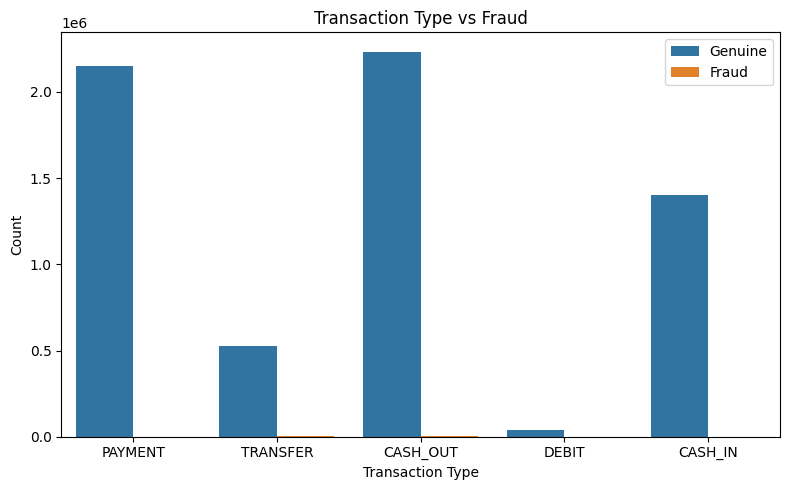

Chart saved


In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title('Transaction Type vs Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(['Genuine', 'Fraud'])
plt.tight_layout()
plt.savefig('../reports/fraud_by_type.png')
plt.show()
print("Chart saved")

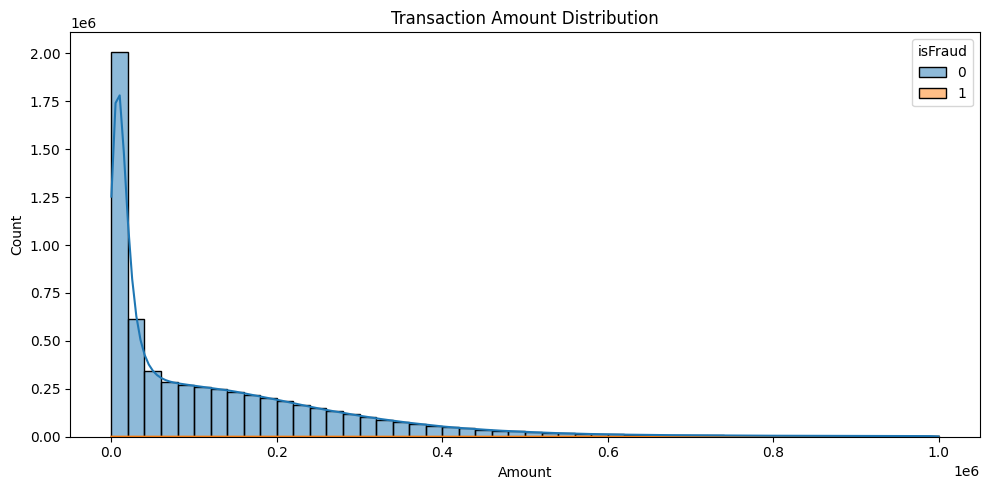

Chart saved


In [16]:
plt.figure(figsize=(10,5))
sns.histplot(data=df[df['amount'] < 1000000], x='amount', hue='isFraud', bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.tight_layout()
plt.savefig('../reports/amount_distribution.png')
plt.show()
print("Chart saved")

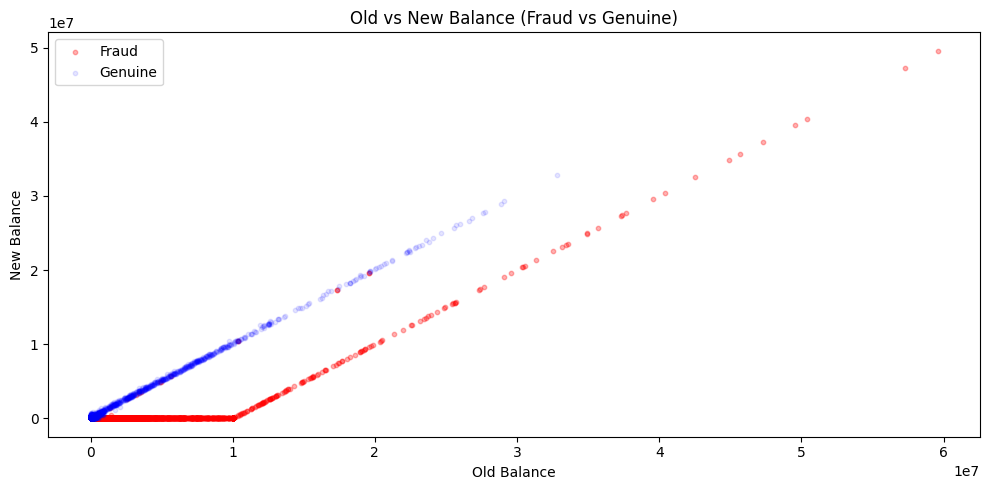

Chart saved


In [17]:
plt.figure(figsize=(10,5))
plt.scatter(fraud['oldbalanceOrg'], fraud['newbalanceOrig'], 
            alpha=0.3, color='red', label='Fraud', s=10)
plt.scatter(genuine['oldbalanceOrg'].sample(5000, random_state=42), 
            genuine['newbalanceOrig'].sample(5000, random_state=42), 
            alpha=0.1, color='blue', label='Genuine', s=10)
plt.xlabel('Old Balance')
plt.ylabel('New Balance')
plt.title('Old vs New Balance (Fraud vs Genuine)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/balance_pattern.png')
plt.show()
print("Chart saved")

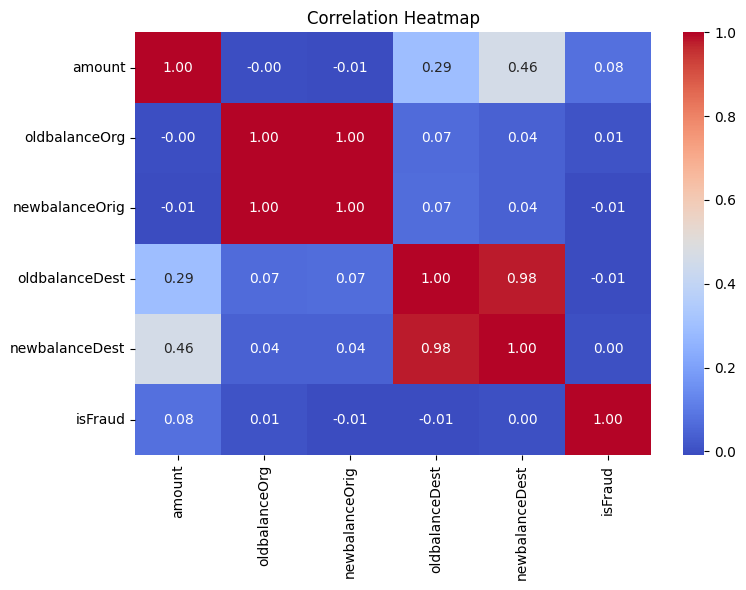

In [18]:
cols = ['amount','oldbalanceOrg','newbalanceOrig',
        'oldbalanceDest','newbalanceDest','isFraud']
plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/correlation.png')
plt.show()

In [19]:
print("=" * 50)
print("KEY FINDINGS FROM EDA")
print("=" * 50)
print(f"Total transactions:     {len(df):,}")
print(f"Total fraud cases:      {df['isFraud'].sum():,}")
print(f"Fraud percentage:       {df['isFraud'].mean()*100:.2f}%")
print(f"Fraud only in types:    {fraud['type'].unique()}")
print(f"Avg fraud amount:       {fraud['amount'].mean():,.2f}")
print(f"Avg genuine amount:     {genuine['amount'].mean():,.2f}")
print(f"Fraud drains account:   oldbalance={fraud['oldbalanceOrg'].mean():,.0f} → newbalance={fraud['newbalanceOrig'].mean():,.0f}")
print("=" * 50)

KEY FINDINGS FROM EDA
Total transactions:     6,362,620
Total fraud cases:      8,213
Fraud percentage:       0.13%
Fraud only in types:    ['TRANSFER' 'CASH_OUT']
Avg fraud amount:       1,467,967.30
Avg genuine amount:     178,197.04
Fraud drains account:   oldbalance=1,649,668 → newbalance=192,393


In [20]:
print("EDA Complete. Notebook 01 done.")
print("Charts saved in reports/ folder")
print("Ready for Notebook 02 - Preprocessing")

EDA Complete. Notebook 01 done.
Charts saved in reports/ folder
Ready for Notebook 02 - Preprocessing
